# Importacion de liberias

In [141]:
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Cargue de datos

In [142]:
df_recaudo = pd.read_excel('../data/processed/dataset_recaudo.xlsx')

In [143]:
df_recaudo.groupby('year').sum('recaudo')

,recaudo,empresas,trabajadores,salario_minimo,salario_promedio,masa_salarial,desempleo,inflacion,pib,trm,...,lag_2,lag_3,lag_6,lag_12,ma_3,ma_6,ma_12,std_6,pct_1,pct_12
year,,,,,,,,,,,,,,,,,,,,,
2015,616224290085,502416,9041254,7732200,20058161,15115169237125,128.576684,55.339490,1226.827466,34588.29,...,5.023086e+11,4.517329e+11,2.963096e+11,0.000000e+00,4.576658e+11,3.061438e+11,0.000000e+00,1.362654e+10,0.195448,0.000000
2016,708464772803,529218,9520342,8273460,21415819,16989583286894,119.265903,41.339333,1276.512149,35222.41,...,6.949083e+11,6.863801e+11,6.665217e+11,6.162243e+11,6.935765e+11,6.830242e+11,6.591104e+11,3.351523e+10,0.166651,1.813855
2017,820281663840,557203,10048923,8852604,22983151,19245329579241,109.727849,54.857016,1320.413494,35932.99,...,8.041450e+11,7.933940e+11,7.624366e+11,7.084648e+11,8.030862e+11,7.877711e+11,7.594405e+11,3.455108e+10,0.144086,1.906239
2018,914081119563,579035,10420053,9374904,24430290,21215089687796,129.712796,42.049875,1367.623989,37971.34,...,8.944463e+11,8.847993e+11,8.623950e+11,8.202817e+11,8.944108e+11,8.821292e+11,8.593930e+11,4.353893e+10,0.159422,1.369172
2019,1038711621196,607252,10924363,9937392,25822076,23507098404394,122.900746,53.729419,1426.275503,38587.26,...,1.018126e+12,1.012543e+12,9.792008e+11,9.140811e+11,1.018539e+12,1.003779e+12,9.730286e+11,4.156411e+10,0.180407,1.651253
2020,987690494963,604443,10879677,10533636,27475591,24912714286756,156.304174,42.459273,1354.893851,39473.68,...,9.953572e+11,9.960578e+11,1.010769e+12,1.038712e+12,9.944774e+11,1.000984e+12,1.013702e+12,6.381506e+10,0.021174,-0.588404
2021,1213878474179,659611,11868810,10902312,28231276,27922102407996,130.653978,53.684541,1532.219266,41542.58,...,1.171709e+12,1.156086e+12,1.104221e+12,9.876905e+11,1.173767e+12,1.147138e+12,1.091680e+12,5.277475e+10,0.212240,2.767883
2022,1495063327375,692049,12452440,12000000,31290480,32471126189244,121.237626,66.135333,1604.088593,42213.26,...,1.439257e+12,1.406579e+12,1.337152e+12,1.213878e+12,1.438961e+12,1.400786e+12,1.332210e+12,6.926887e+10,0.204991,2.781393
2023,1838270730199,723188,13030394,13920000,36313791,39433976145803,108.131150,52.541763,1661.159871,42944.37,...,1.785469e+12,1.765572e+12,1.672373e+12,1.495063e+12,1.784923e+12,1.745026e+12,1.657267e+12,6.779251e+10,0.236976,2.781116


# Entrenamiento y testeo de modelos

In [144]:
df = df_recaudo.copy()
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.set_index("fecha")
serie = df["recaudo"]
serie_log = np.log(serie)

### Boruta

In [145]:
X = df.drop(columns=["recaudo"])
y = df['recaudo']

In [146]:
numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

X_pre = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_pre = pd.DataFrame(
    X_pre,
    columns=feature_names,
    index=X.index
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    random_state=42
)

boruta.fit(X_pre.values, y.values)
variables = X_pre.columns[boruta.support_]

print(variables)

ranking = pd.DataFrame({
    "Variable": X_pre.columns,
    "Ranking": boruta.ranking_,
    "Seleccionada": boruta.support_
})

ranking.sort_values("Ranking")

Index(['num__empresas', 'num__trabajadores', 'num__salario_minimo',
       'num__salario_promedio', 'num__masa_salarial', 'num__desempleo',
       'num__inflacion', 'num__pib', 'num__trm', 'num__precio_petroleo',
       'num__indice_confianza', 'num__year', 'num__lag_1', 'num__lag_2',
       'num__lag_3', 'num__lag_6', 'num__lag_12', 'num__ma_3', 'num__ma_6',
       'num__ma_12', 'num__pct_12'],
      dtype='object')


,Variable,Ranking,Seleccionada
0,num__empresas,1,True
24,num__pct_12,1,True
21,num__ma_12,1,True
20,num__ma_6,1,True
19,num__ma_3,1,True
18,num__lag_12,1,True
17,num__lag_6,1,True
16,num__lag_3,1,True
15,num__lag_2,1,True
14,num__lag_1,1,True


In [147]:

variables_boruta = [
    "empresas",
    "pct_12",
    "ma_12",
    "ma_6",
    "ma_3",
    "lag_12",
    "lag_6",
    "lag_3",
    "lag_2",
    "lag_1",
    "year",
    "masa_salarial",
    "trabajadores",
    "precio_petroleo",
    "trm",
    "pib",
    "inflacion",
    "desempleo",
    "indice_confianza",
    "salario_promedio",
    "salario_minimo"
]

n_test = 12

X = df.iloc[:,df.columns.isin(variables_boruta)]
y = df['recaudo']

# Variable objetivo
y_train = y[:-n_test]
y_test = y[-n_test:]

# Variables exógenas
X_train = X[:-n_test]
X_test = X[-n_test:]

fechas_train = X_train.index
fechas_test = X_test.index


print(X_train.index.max())
print(X_test.index.min())

2024-12-01 00:00:00
2025-01-01 00:00:00


In [148]:
numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

categorical_features = [c for c in categorical_features if c != "fecha"]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

In [149]:
modelo_xgb = XGBRegressor(
    obejetive = 'reg:squarederror',
    n_estimators = 500,
    learning_rate = 0.03,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 123)

pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", modelo_xgb)
])
pipeline_xgb.fit(X_train, y_train)

C:\Users\NATHNIEAYA\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [20:41:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obejetive" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['empresas', 'trabajadores',
                                                   'salario_minimo',
                                                   'salario_promedio',
                                                   'masa_salarial', 'desempleo',
                                                   'inflacion', 'pib', 'trm',
                                                   'precio_petroleo',
                                                   'indice_confianza', 'year',
                                                   'lag_1', 'lag_2', 'lag_3',
                                                   'lag_6', 'lag_12', 'ma_3',
                                                   'ma_6', 'm...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None,
                              obejetive='reg:squarederror', ...))])

In [150]:
pred_preelimina = pipeline_xgb.predict(X_test)
feature_names = pipeline_xgb.named_steps[
    "preprocessor"
].get_feature_names_out()

importancias = pd.DataFrame({

    "Variable":feature_names,

    "Importancia":pipeline_xgb.named_steps[
        "model"
    ].feature_importances_

})

importancias.sort_values(
    "Importancia",
    ascending=False
)

,Variable,Importancia
12,num__lag_1,0.236411
1,num__trabajadores,0.236152
0,num__empresas,0.136933
14,num__lag_3,0.126454
2,num__salario_minimo,0.103896
4,num__masa_salarial,0.061341
7,num__pib,0.036683
3,num__salario_promedio,0.024245
13,num__lag_2,0.013715
16,num__lag_12,0.010643


A pesar de que boruta recomendó entre las variables más relacionadas con el recaudo las mencionadas anteriormente, al momento de realizar el entrenamieto con xgboost se identificó que son las que menos influyen en su resultado, por lo tanto se decide realizar el entrenamiento de otros modelos sin incluir las variables de entorno, unicamente se tendran en cuenta las creadas en el eda

### Separar train y test sin exo

In [151]:
n_test = 12
train = serie_log[:-n_test]
test = serie_log[-n_test:]

In [152]:
print(train.index.max())
print(test.index.min())

2024-12-01 00:00:00
2025-01-01 00:00:00


In [153]:
df.columns

Index(['recaudo', 'empresas', 'trabajadores', 'salario_minimo',
       'salario_promedio', 'masa_salarial', 'desempleo', 'inflacion', 'pib',
       'trm', 'precio_petroleo', 'indice_confianza', 'mes_prima', 'mes',
       'year', 'trimestre', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
       'ma_3', 'ma_6', 'ma_12', 'std_6', 'pct_1', 'pct_12'],
      dtype='object')

### Separar train y test con exo

In [154]:
features = [
    'mes_prima', 'mes',
       'year', 'trimestre', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
       'ma_3', 'ma_6', 'ma_12', 'std_6', 'pct_1', 'pct_12'
]

target = 'recaudo'

In [155]:
X = df.iloc[:,df.columns.isin(features)]
y = df[target]

# Variable objetivo
y_train = y[:-n_test]
y_test = y[-n_test:]

# Variables exógenas
X_train = X[:-n_test]
X_test = X[-n_test:]

fechas_train = X_train.index
fechas_test = X_test.index


print(X_train.index.max())
print(X_test.index.min())

2024-12-01 00:00:00
2025-01-01 00:00:00


### SARIMAX

In [156]:
modelo = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado = modelo.fit()
print(resultado.summary())

c:\Program Files\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Program Files\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                            recaudo   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 168.268
Date:                            Thu, 30 Jul 2026   AIC                           -326.536
Time:                                    20:41:44   BIC                           -313.266
Sample:                                01-01-2015   HQIC                          -321.159
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0790      0.253     -0.312      0.755      -0.576       0.418
ma.L1         -0.4617      0.235   

In [157]:
pred = resultado.get_forecast(steps=n_test)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

In [158]:
pred_ci

,lower recaudo,upper recaudo
2025-01-01,25.901886,26.090898
2025-02-01,25.931891,26.139887
2025-03-01,25.924301,26.152920
2025-04-01,25.911795,26.159079
2025-05-01,25.944900,26.209554
2025-06-01,25.955160,26.236112
2025-07-01,25.911475,26.207829
2025-08-01,25.890477,26.201472
2025-09-01,25.895295,26.220272
2025-10-01,25.917129,26.255510


In [159]:
pred_real = np.exp(pred_mean)
test_real = np.exp(test)
train_real = np.exp(train)
lower = np.exp(pred_ci.iloc[:,0])
upper = np.exp(pred_ci.iloc[:,1])

print({'pred_real':pred_real})
print({'test_real':test_real})
print({'train_real':train_real})
print({'lower':lower})
print({'upper':upper})

{'pred_real': 2025-01-01    1.950247e+11
2025-02-01    2.028817e+11
2025-03-01    2.034346e+11
2025-04-01    2.027901e+11
2025-05-01    2.114442e+11
2025-06-01    2.153728e+11
2025-07-01    2.077605e+11
2025-08-01    2.049382e+11
2025-09-01    2.073727e+11
2025-10-01    2.133755e+11
2025-11-01    2.152673e+11
2025-12-01    2.237318e+11
Freq: MS, Name: predicted_mean, dtype: float64}
{'test_real': fecha
2025-01-01    1.894573e+11
2025-02-01    2.032389e+11
2025-03-01    2.052120e+11
2025-04-01    2.059261e+11
2025-05-01    2.175686e+11
2025-06-01    2.145403e+11
2025-07-01    2.082903e+11
2025-08-01    1.993420e+11
2025-09-01    2.077978e+11
2025-10-01    2.094811e+11
2025-11-01    2.230186e+11
2025-12-01    2.238215e+11
Name: recaudo, dtype: float64}
{'train_real': fecha
2015-01-01    4.647870e+10
2015-02-01    4.921521e+10
2015-03-01    4.666537e+10
2015-04-01    4.918473e+10
2015-05-01    5.392901e+10
                  ...     
2024-08-01    1.748276e+11
2024-09-01    1.771848e+11
20

In [160]:
rmse_sarimax = np.sqrt(mean_squared_error(test_real, pred_real))
mae_sarimax = mean_absolute_error(test_real, pred_real)
mape_sarimax = mean_absolute_percentage_error(test_real, pred_real)

print("RMSE :", rmse_sarimax)
print("MAE  :", mae_sarimax)
print("MAPE :", mape_sarimax)

RMSE : 3972339878.214841
MAE  : 3006772532.651095
MAPE : 0.014456094205934758


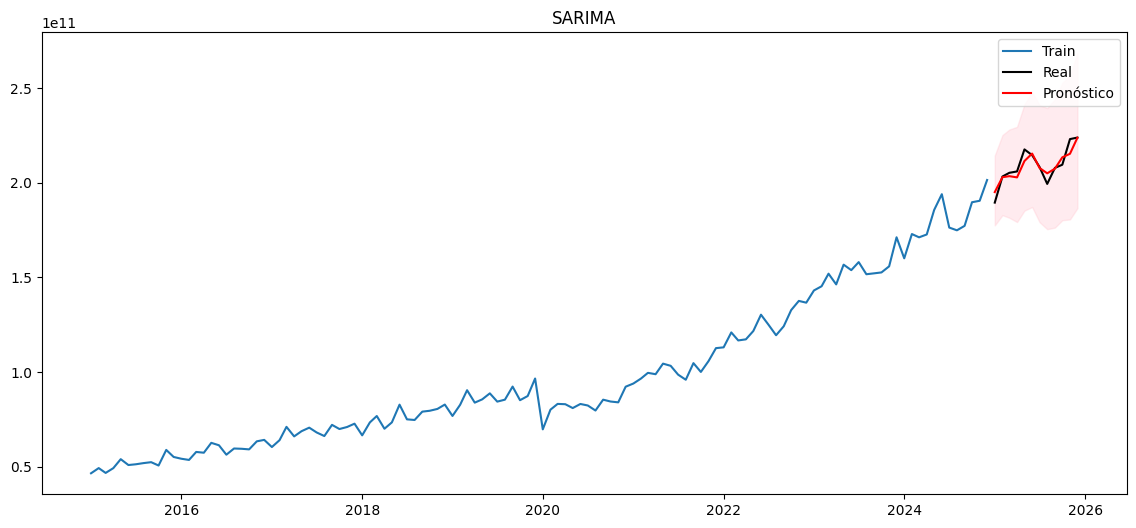

In [161]:
plt.figure(figsize=(14,6))
plt.plot(train_real, label="Train")
plt.plot(test_real, label="Real", color="black")
plt.plot(pred_real, label="Pronóstico", color="red")

plt.fill_between(
    pred_real.index,
    lower,
    upper,
    color="pink",
    alpha=0.3
)

plt.legend()
plt.title("SARIMA")
plt.show()

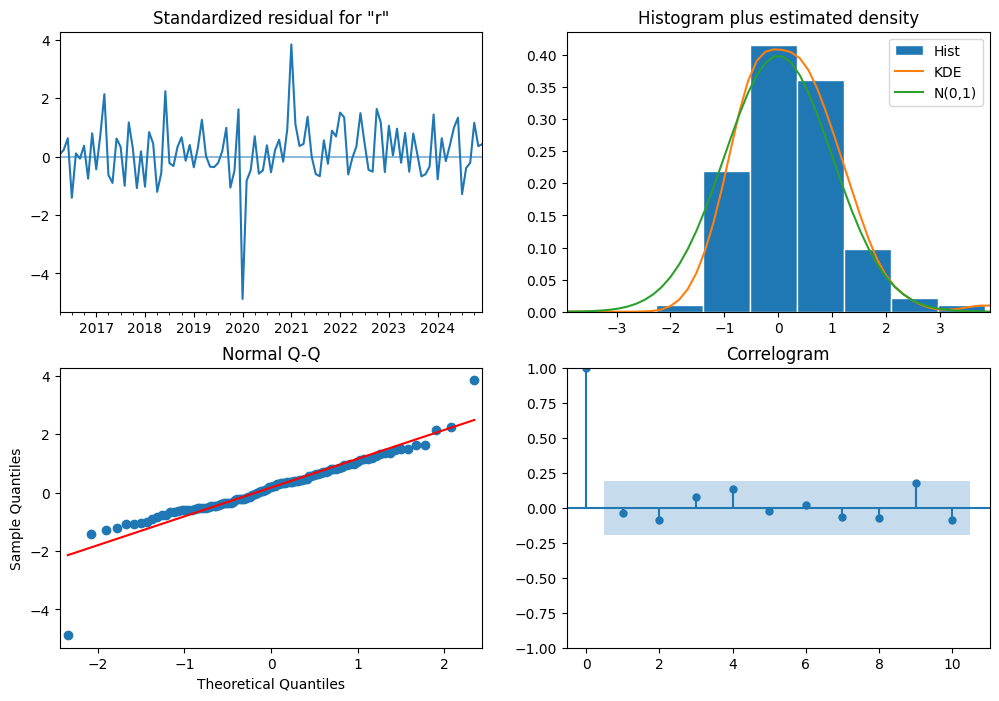

In [162]:
resultado.plot_diagnostics(figsize=(12,8))
plt.show()

In [163]:
pred_2026 = resultado.get_forecast(steps=24)
pred_mean_2026 = pred_2026.predicted_mean
pred_ci_2026 = pred_2026.conf_int()

pred_real_2026 = np.exp(pred_mean_2026)
lower = np.exp(pred_ci_2026.iloc[:,0])
upper = np.exp(pred_ci_2026.iloc[:,1])

print({'pred_real':pred_real})
print({'test_real':test_real})
print({'train_real':train_real})
print({'lower':lower})
print({'upper':upper})


{'pred_real': 2025-01-01    1.950247e+11
2025-02-01    2.028817e+11
2025-03-01    2.034346e+11
2025-04-01    2.027901e+11
2025-05-01    2.114442e+11
2025-06-01    2.153728e+11
2025-07-01    2.077605e+11
2025-08-01    2.049382e+11
2025-09-01    2.073727e+11
2025-10-01    2.133755e+11
2025-11-01    2.152673e+11
2025-12-01    2.237318e+11
Freq: MS, Name: predicted_mean, dtype: float64}
{'test_real': fecha
2025-01-01    1.894573e+11
2025-02-01    2.032389e+11
2025-03-01    2.052120e+11
2025-04-01    2.059261e+11
2025-05-01    2.175686e+11
2025-06-01    2.145403e+11
2025-07-01    2.082903e+11
2025-08-01    1.993420e+11
2025-09-01    2.077978e+11
2025-10-01    2.094811e+11
2025-11-01    2.230186e+11
2025-12-01    2.238215e+11
Name: recaudo, dtype: float64}
{'train_real': fecha
2015-01-01    4.647870e+10
2015-02-01    4.921521e+10
2015-03-01    4.666537e+10
2015-04-01    4.918473e+10
2015-05-01    5.392901e+10
                  ...     
2024-08-01    1.748276e+11
2024-09-01    1.771848e+11
20

In [190]:
predicciones_2026 = pred_real_2026.reset_index()
predicciones_2026.columns = ["Fecha", "Prediccoin aporte"]

In [194]:
predicciones_2026[predicciones_2026['Fecha'] >= '2026-01-01'].to_excel('../data/results/dataset_proyeccion.xlsx', index=False)

### XGBOOST

In [166]:
numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

categorical_features = [c for c in categorical_features if c != "fecha"]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

In [167]:
modelo_xgb = XGBRegressor(
    obejetive = 'reg:squarederror',
    n_estimators = 500,
    learning_rate = 0.03,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 123)

pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", modelo_xgb)
])
pipeline_xgb.fit(X_train, y_train)

C:\Users\NATHNIEAYA\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [20:41:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obejetive" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['mes_prima', 'mes', 'year',
                                                   'lag_1', 'lag_2', 'lag_3',
                                                   'lag_6', 'lag_12', 'ma_3',
                                                   'ma_6', 'ma_12', 'std_6',
                                                   'pct_1', 'pct_12']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(d...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None,
                              obejetive='reg:squarederror', ...))])

In [168]:
pred = pipeline_xgb.predict(X_test)

In [169]:
feature_names = pipeline_xgb.named_steps[
    "preprocessor"
].get_feature_names_out()

importancias = pd.DataFrame({

    "Variable":feature_names,

    "Importancia":pipeline_xgb.named_steps[
        "model"
    ].feature_importances_

})

importancias.sort_values(
    "Importancia",
    ascending=False
)

,Variable,Importancia
3,num__lag_1,0.328142
2,num__year,0.199930
5,num__lag_3,0.099115
8,num__ma_3,0.093400
4,num__lag_2,0.085854
10,num__ma_12,0.064611
7,num__lag_12,0.055377
6,num__lag_6,0.038941
9,num__ma_6,0.025261
13,num__pct_12,0.004797


In [170]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred))
mae_xgb = mean_absolute_error(y_test, pred)
mape_xgb = mean_absolute_percentage_error(y_test, pred)

print("RMSE :", rmse_xgb)
print("MAE  :", mae_xgb)
print("MAPE :", mape_xgb)

RMSE : 21352160350.723755
MAE  : 20112311802.5
MAPE : 0.09495848139035988


In [171]:
lower = pred - rmse_xgb
upper = pred + rmse_xgb

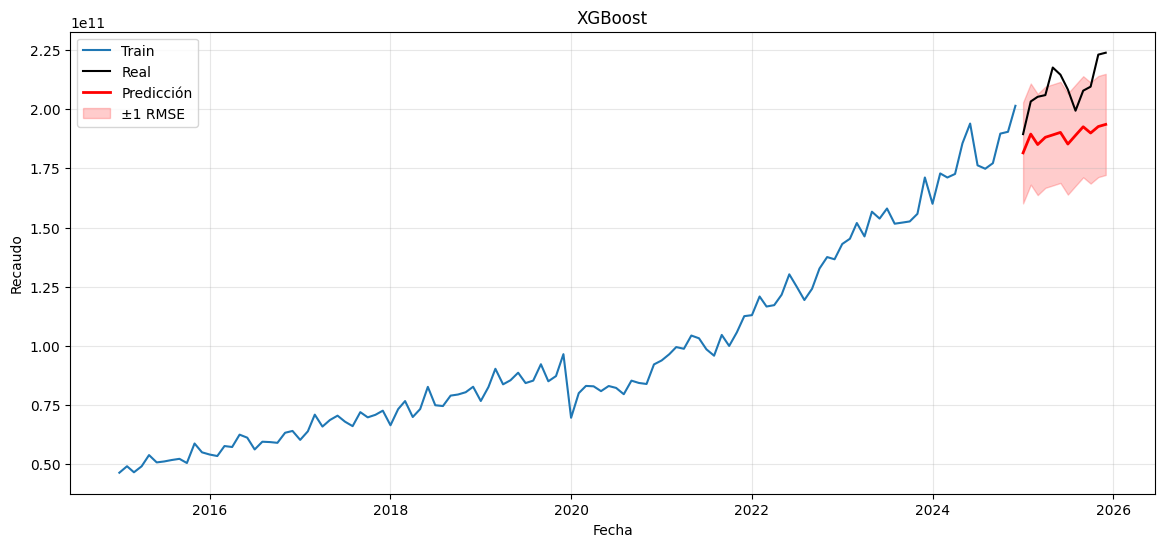

In [172]:
plt.figure(figsize=(14,6))

plt.plot(fechas_train, y_train, label="Train")
plt.plot(fechas_test, y_test, color="black", label="Real")
plt.plot(fechas_test, pred, color="red", linewidth=2, label="Predicción")

plt.fill_between(
    fechas_test,
    lower,
    upper,
    color="red",
    alpha=0.20,
    label="±1 RMSE"
)

plt.legend()
plt.title("XGBoost")
plt.xlabel("Fecha")
plt.ylabel("Recaudo")
plt.grid(alpha=0.3)

plt.show()

Debido al rendimiendo del modelo se decide hacer busqueda de hiperparametros para validar si es posible superar a SARIMA

### XGBOOST + pharamsgrid

In [173]:
param_grid = {
    "model__n_estimators":[200,400,600],
    "model__max_depth":[3,4,5],
    "model__learning_rate":[0.01,0.03,0.05],
    "model__subsample":[0.8,1],
    "model__colsample_bytree":[0.8,1]
}

In [174]:
grid = GridSearchCV(
    pipeline_xgb,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

C:\Users\NATHNIEAYA\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [20:42:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obejetive" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['mes_prima',
                                                                          'mes',
                                                                          'year',
                                                                          'lag_1',
                                                                          'lag_2',
                                                                          'lag_3',
                                                                          'lag_6',
                                                                          'lag_12',
                                                                          'ma_3',
                                                                          'ma_6',
                                                                          'ma_12',
                                                                          'std_6',
                                                                          'pct_1',
                                                                          'pct_12']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent'...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=500,
                                                     n_jobs=None,
                                                     num_parallel_tree=None,
                                                     obejetive='reg:squarederror', ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1],
                         'model__learning_rate': [0.01, 0.03, 0.05],
                         'model__max_depth': [3, 4, 5],
                         'model__n_estimators': [200, 400, 600],
                         'model__subsample': [0.8, 1]},
             scoring='neg_root_mean_squared_error')

In [175]:
print(grid.best_params_)
best_model = grid.best_estimator_

{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 600, 'model__subsample': 0.8}


In [176]:
pred_xgb = best_model.predict(X_test)

In [177]:
rmse_xgb_g = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae_xgb_g = mean_absolute_error(y_test, pred_xgb)
mape_xgb_g = mean_absolute_percentage_error(y_test, pred_xgb)

print("RMSE :", rmse_xgb_g)
print("MAE  :", mae_xgb_g)
print("MAPE :", mape_xgb_g)

RMSE : 23097271370.585
MAE  : 21992919205.166668
MAPE : 0.1039866175826492


In [178]:
lower = pred_xgb - rmse_xgb_g
upper = pred_xgb + rmse_xgb_g

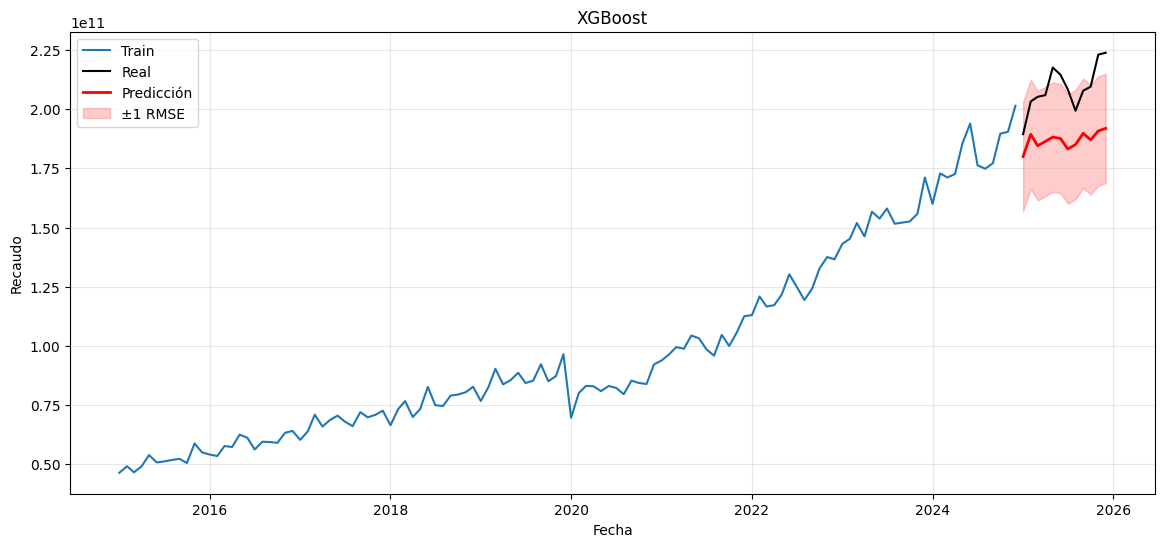

In [179]:
plt.figure(figsize=(14,6))

plt.plot(fechas_train, y_train, label="Train")
plt.plot(fechas_test, y_test, color="black", label="Real")
plt.plot(fechas_test, pred_xgb, color="red", linewidth=2, label="Predicción")

plt.fill_between(
    fechas_test,
    lower,
    upper,
    color="red",
    alpha=0.20,
    label="±1 RMSE"
)

plt.legend()
plt.title("XGBoost")
plt.xlabel("Fecha")
plt.ylabel("Recaudo")
plt.grid(alpha=0.3)

plt.show()

### LXGBM

In [180]:
from lightgbm import LGBMRegressor

In [181]:
modelo_lgbm = LGBMRegressor(
    n_estimators = 500,
    learning_rate = 0.03,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 123)

pipeline_lgbm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", modelo_lgbm)
])
pipeline_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 472
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 17
[LightGBM] [Info] Start training from score 98321738547,199997
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['mes_prima', 'mes', 'year',
                                                   'lag_1', 'lag_2', 'lag_3',
                                                   'lag_6', 'lag_12', 'ma_3',
                                                   'ma_6', 'ma_12', 'std_6',
                                                   'pct_1', 'pct_12']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['trimestre'])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03,
                               max_depth=4, n_estimators=500, random_state=123,
                               subsample=0.8))])

In [182]:
pred_lgbm = pipeline_lgbm.predict(X_test)

In [183]:
feature_names = pipeline_lgbm.named_steps[
    "preprocessor"
].get_feature_names_out()

importancias = pd.DataFrame({

    "Variable":feature_names,

    "Importancia":pipeline_lgbm.named_steps[
        "model"
    ].feature_importances_

})

importancias.sort_values(
    "Importancia",
    ascending=False
)

,Variable,Importancia
11,num__std_6,291
1,num__mes,257
12,num__pct_1,256
13,num__pct_12,198
3,num__lag_1,186
2,num__year,175
10,num__ma_12,111
7,num__lag_12,107
6,num__lag_6,85
5,num__lag_3,80


In [184]:
rmse_lgbm = np.sqrt(mean_squared_error(y_test, pred_lgbm))
mae_lgbm = mean_absolute_error(y_test, pred_lgbm)
mape_lgmb = mean_absolute_percentage_error(y_test, pred_lgbm)

print("RMSE :", rmse_lgbm)
print("MAE  :", mae_lgbm)
print("MAPE :", mape_lgmb)

RMSE : 38085894996.03079
MAE  : 37102259990.35933
MAPE : 0.17643955098825548


In [185]:
lower = pred_lgbm - rmse_lgbm
upper = pred_lgbm + rmse_lgbm

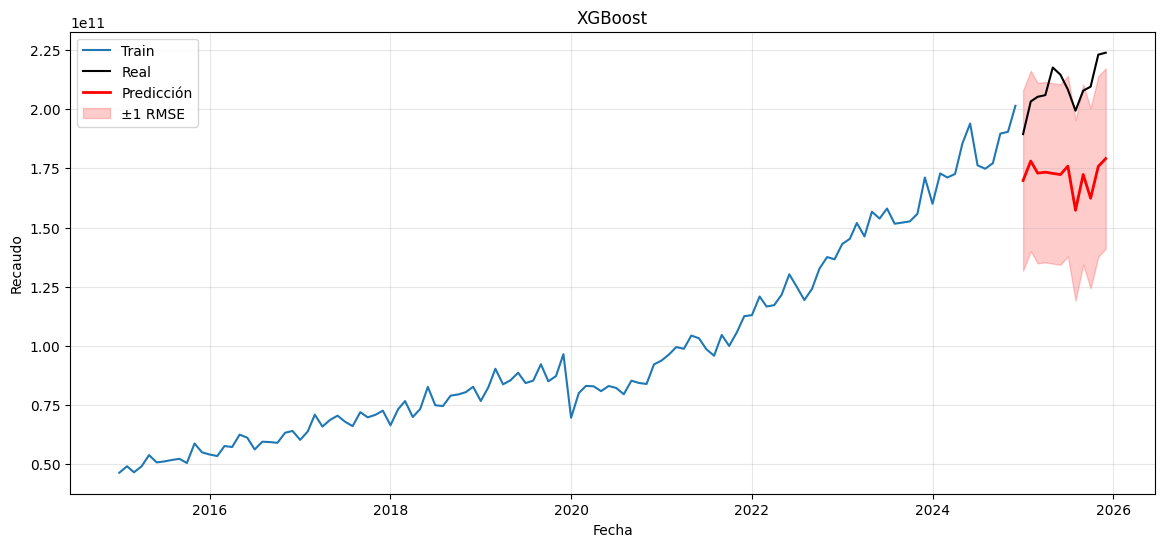

In [186]:
plt.figure(figsize=(14,6))

plt.plot(fechas_train, y_train, label="Train")
plt.plot(fechas_test, y_test, color="black", label="Real")
plt.plot(fechas_test, pred_lgbm, color="red", linewidth=2, label="Predicción")

plt.fill_between(
    fechas_test,
    lower,
    upper,
    color="red",
    alpha=0.20,
    label="±1 RMSE"
)

plt.legend()
plt.title("XGBoost")
plt.xlabel("Fecha")
plt.ylabel("Recaudo")
plt.grid(alpha=0.3)

plt.show()

### Conclusiones
* Para el modelamiento no se tuvieron en cuenta las variables exogenas entregadas en el set de datos puesto que no hay garantia de contar con esta información a futuro dato que no corresponden a los cambios del negocio sino a cambios macroeconomicos del país, lo cual no permitiria realizar las predicciones correctamente dado que serian necesarias para las predicciones del modelo, por lo tanto se crearion variables propias de los datos como lo son 'mes_prima', 'mes','year', 'trimestre', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',    'ma_3', 'ma_6', 'ma_12', 'std_6', 'pct_1', 'pct_12'.
* Se evaluaron tres enfoques de pronóstico: SARIMA, XGBoost y LightGBM, utilizando las mismas métricas de evaluación sobre el conjunto de prueba. De acuerdo con los resultados obtenidos, SARIMA presentó el mejor desempeño predictivo, alcanzando el menor error entre los modelos comparados.
* el modelo SARIMA obtuvo el mejor rendimiento para proyectar el recaudo mensual, dado que fue el mas acertado con un error promedio del 1.45% de las predicciones

In [187]:
joblib.dump(resultado, "../models/modelo_forecast_presupuesto.pkl")


['../models/modelo_forecast_presupuesto.pkl']